# Identifying Low-Risk Aircraft for New Aviation Division Launch
## Project Overview
* This project is a strategic initiative to support the company's expansion into the aviation industry with data-driven insights to inform initial aircraft acquisition decisions.

* By thoroughly analyzing historical aviation incident data, this project will quantify key risk factors such as accident frequency, damage severity, and human injury rates for various aircraft makes and models. 

* The ultimate goal is to identify and recommend aircraft that exhibit the lowest overall risk profiles, thereby enabling the head of the new division to make strategically sound purchases that minimize financial liabilities, operational disruptions, and safety concerns, ensuring a secure and successful entry into the aviation industry.

## Business Understanding
### 1. Project Purpose
This project is a strategic initiative to support the company's expansion into the aviation industry. The primary purpose is to conduct a comprehensive analysis of aircraft risk profiles to identify and recommend the most suitable low-risk aircraft for the new aviation division's initial fleet. This analysis will provide the necessary data and insights to mitigate the significant risks associated with aircraft acquisition and operation, thereby ensuring a stable and successful launch of the new business venture.

### 2. Problem Statement
The company is entering the aviation sector with a limited understanding of the inherent risks, which include, but are not limited to, accident rates, operational complexity, aircraft damage potential, and the human cost of incidents. A lack of data-driven insights in this area could lead to sub-optimal purchasing decisions, resulting in financial losses, operational inefficiencies, and significant safety liabilities. The problem is to transform raw aviation incident data into actionable intelligence that quantifies these risks and guides the selection of a low-risk, high-reliability aircraft portfolio.

### 3. Project Scope
This project will focus on the following key areas:
Data Analysis: Utilizing the provided "Aviation_Data.csv" dataset, the project will analyze historical aviation incidents to assess risk factors.

  * Risk Factor Quantification: Key risk factors such as accident frequency, aircraft damage severity, and human injury rates will be quantified and benchmarked across different aircraft makes and models.

  * Aircraft Filtering: The analysis will be filtered to focus on aircraft types relevant to commercial and private enterprises, excluding categories like amateur-built.

 * Risk Profile Generation: A comprehensive risk profile will be developed for each significant aircraft make and model, considering accident severity, operational context (e.g., phase of flight, weather conditions), and human impact.

  * Recommendation & Actionable Insights: The project will culminate in a set of clear, actionable recommendations for the head of the new aviation division, identifying specific aircraft makes and models that represent the lowest overall risk for initial acquisition. The report will explain the rationale behind these recommendations, highlighting key risk mitigation strategies.

### Key Business Questions to Address:

1. What are the primary risk factors associated with aircraft ownership and operation (e.g., accident rates,

   operational complexity, human impact)?

3. How can these risk factors be quantified or assessed for different aircraft types?

4. Which specific aircraft models exhibit the lowest overall risk profile based on a comprehensive evaluation of these factors?

5. What are the key characteristics of these low-risk aircraft that make them suitable for the company's initial ventures?

6. What actionable insights and recommendations can be provided to the head of the aviation division to guide their aircraft purchasing

   decisions?

## Data Understanding
The data sources for this analysis will be pulled from the National Transportation Safety Board that includes aviation accident data from 1962 to 2023 about civil aviation accidents and selected incidents in the United States and international waters.
The data is contained in a csv file "Aviation_Data.csv"

### 1. Loading the Data with Pandas
In the cell below, we:

  * Import and alias pandas as pd
  * Import and alias numpy as np
  * Import and alias seaborn as sns
  * Import and alias matplotlib.pyplot as plt
  * Set Matplotlib visualizations to display inline in the notebook

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("Aviation_Data.csv", low_memory=False )
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


### 2. Famializing with the Data
   * Understanding the dimensionality of the dataset
   * Investigating what type of data it contains, and the data types used to store it
   * Discovering how missing values are encoded, and how many there are
   * Getting a feel for what information it does and doesn't contain

In [3]:
# dimensionality of the dataset
df.shape

(90348, 31)

In [4]:
# Investigating what type of data it contains, and the data types used to store it
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

From the information above we can deduce that: most of the items are objects and only 5 out of the 30 columns are floats. And Event.Date and Publication.Date are objects instead of datetime.

In [5]:
# Discovering how missing values are encoded, and how many there are
df.isnull().sum()

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40216
Airport.Name              37644
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2841
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8555
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7843
Publication.Date          16689
dtype: i

In [6]:
df['Amateur.Built'].unique()

array(['No', 'Yes', nan], dtype=object)

In [7]:
df['Aircraft.Category'].unique()

array([nan, 'Airplane', 'Helicopter', 'Glider', 'Balloon', 'Gyrocraft',
       'Ultralight', 'Unknown', 'Blimp', 'Powered-Lift', 'Weight-Shift',
       'Powered Parachute', 'Rocket', 'WSFT', 'UNK', 'ULTR'], dtype=object)

In [8]:
df['Investigation.Type'].value_counts()

Investigation.Type
Accident      85015
Incident       3874
25-09-2020      702
26-09-2020       60
02-02-2021       39
              ...  
13-09-2021        1
04-08-2021        1
05-08-2022        1
03-11-2020        1
06-01-2021        1
Name: count, Length: 71, dtype: int64

In [9]:
df['Event.Id'].value_counts()

Event.Id
20001212X19172    3
20001214X45071    3
20220730105623    2
20051213X01965    2
20001212X16765    2
                 ..
20001211X14216    1
20001211X14239    1
20001211X14207    1
20001211X14204    1
20221230106513    1
Name: count, Length: 87951, dtype: int64

In [10]:
# Getting a feel for what information it does and doesn't contain
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [11]:
df['Aircraft.damage'].unique()

array(['Destroyed', 'Substantial', 'Minor', nan, 'Unknown'], dtype=object)

This dataset primarily contains accident and incident data which is excellent for analyzing accident rates, injury severity, and aircraft damage, which are critical risk factors. Below is a sample of columns and the description of what they contain.

 * **Aircraft.damage**: This is crucial. It directly indicates the severity of an incident. "Destroyed" or "Substantial" damage implies higher risk and potentially higher costs.

* **Injury.Severity**: This column is paramount as it reflects the human cost of an accident. Total Fatal, Serious, and Minor Injuries, as well as Uninjured, provide a comprehensive picture of the impact on human life, which is a key risk factor for any company.

* **Make**: This identifies the manufacturer of the aircraft. Different manufacturers have different safety records, design philosophies, and support networks.

* **Model**: This is even more specific than 'Make'. Different models within the same manufacturer can have vastly different risk profiles due to design, age, or operational history.

* **Aircraft.Category**: This classifies the type of aircraft (e.g., "Airplane," "Rotorcraft," "Glider"). Different categories have inherent risk differences and different operational requirements.

* **Total.Fatal.Injuries, Total.Serious.Injuries, Total.Minor.Injuries, Total.Uninjured**: These provide granular details on the human impact of each event, allowing for a more nuanced risk assessment beyond just "Injury.Severity".

* **Accident.Number (or Event.Id)**: While not directly a risk factor, it serves as a unique identifier for each event. Can be used to group and count incidents by aircraft make/model to calculate accident rates.

* **Event.Date**: Useful for analyzing trends over time, identifying if certain models have improved or worsened in safety, and considering the age of the aircraft.

* **Purpose.of.flight**: The purpose of the flight (e.g., "Commercial," "Personal," "Instructional") can significantly influence accident types and frequencies. A commercial enterprise will be most interested in risks relevant to their intended operations.

* **Weather.Condition**: Adverse weather is a known factor in accidents. Analyzing this can help understand if certain aircraft types are more susceptible to weather-related incidents.

* **Broad.phase.of.flight**: This column (e.g., "Takeoff," "Landing," "Cruise") provides context for when accidents occur, which can highlight specific vulnerabilities of an aircraft during different operational phases.


## 3. Data Cleaning and Filtering

In [12]:
# Cleaning the column names 
df.columns = [col.replace(".", "_") for col in df.columns]
df.columns

Index(['Event_Id', 'Investigation_Type', 'Accident_Number', 'Event_Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport_Code',
       'Airport_Name', 'Injury_Severity', 'Aircraft_damage',
       'Aircraft_Category', 'Registration_Number', 'Make', 'Model',
       'Amateur_Built', 'Number_of_Engines', 'Engine_Type', 'FAR_Description',
       'Schedule', 'Purpose_of_flight', 'Air_carrier', 'Total_Fatal_Injuries',
       'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured',
       'Weather_Condition', 'Broad_phase_of_flight', 'Report_Status',
       'Publication_Date'],
      dtype='object')

In [13]:
# checking for duplicate rows in the data
df.duplicated().value_counts()

False    88958
True      1390
Name: count, dtype: int64

In [14]:
# Grouping the duplicates and confirming the data they contain
df[df.duplicated(keep=False)].sort_values(by='Event_Id')

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Purpose_of_flight,Air_carrier,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date
64030,NaN,25-09-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64050,NaN,25-09-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64052,NaN,25-09-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64388,NaN,25-09-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64541,NaN,25-09-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90004,NaN,15-12-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90010,NaN,15-12-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90031,NaN,15-12-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90090,NaN,20-12-2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Dropping the rows of duplicates
df.drop_duplicates(inplace=True)

In [16]:
# Convert Event_Date to datetime
df['Event_Date'] = pd.to_datetime(df['Event_Date'], errors='coerce')

In [17]:
# Filtering out only airplanes and ones that are not Amateur Built.
# The business problem mentions "airplanes for commercial and private enterprises"
df_filtered = df[df['Aircraft_Category'] == 'Airplane'].copy()
df_filtered = df_filtered[df_filtered['Amateur_Built']!= "Yes"]
df_filtered

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Purpose_of_flight,Air_carrier,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,1.0,0.0,IMC,Cruise,Probable Cause,02-01-1983
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,Personal,NaN,1.0,0.0,0.0,0.0,IMC,Takeoff,Probable Cause,02-01-1983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90328,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,14-12-2022
90332,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,Personal,SKY WEST AVIATION INC TRUSTEE,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90335,20221219106475,Accident,WPR23LA069,2022-12-15,"Wichita, KS",United States,373829N,0972635W,ICT,WICHITA DWIGHT D EISENHOWER NT,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,19-12-2022
90336,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,Personal,GERBER RICHARD E,0.0,1.0,0.0,0.0,VMC,NaN,NaN,23-12-2022


In [18]:
# Asserting that we only have airplanes in category and there are no Amateur built 
df_filtered['Amateur_Built'].value_counts()
df_filtered['Aircraft_Category'].value_counts()
print(f"{df_filtered['Amateur_Built'].value_counts()} and {df_filtered['Aircraft_Category'].value_counts()}")

Amateur_Built
No    24417
Name: count, dtype: int64 and Aircraft_Category
Airplane    24434
Name: count, dtype: int64


#### Further cleaning on key columns
Filling missing values in injury or damage columns is essential before performing calculations on them. 
For categorical data, some of them already have unknown as a unique variable, makes sense to fill the na in the categorical columns with 'Unknown' to prevent errors.

In [19]:
# To find the missing values of the df_filtered
df_filtered.isna().sum()

Event_Id                      0
Investigation_Type            0
Accident_Number               0
Event_Date                    0
Location                      7
Country                       7
Latitude                   5259
Longitude                  5265
Airport_Code               8948
Airport_Name               8449
Injury_Severity             813
Aircraft_damage            1274
Aircraft_Category             0
Registration_Number         216
Make                          3
Model                        18
Amateur_Built                17
Number_of_Engines          2562
Engine_Type                3967
FAR_Description             480
Schedule                  21486
Purpose_of_flight          3695
Air_carrier               14078
Total_Fatal_Injuries       2779
Total_Serious_Injuries     2862
Total_Minor_Injuries       2578
Total_Uninjured             729
Weather_Condition          2990
Broad_phase_of_flight     18635
Report_Status              4663
Publication_Date           2014
dtype: i

In [20]:
df_filtered['Total_Fatal_Injuries'].describe()

count    21655.000000
mean         0.692912
std          6.304978
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total_Fatal_Injuries, dtype: float64

In [21]:
df_filtered['Total_Serious_Injuries'].describe()

count    21572.000000
mean         0.304144
std          2.222139
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        161.000000
Name: Total_Serious_Injuries, dtype: float64

In [22]:
# Fill missing injury values with 0 it is a sensible choice since the median/50% for the three is 0.
injury_cols = ['Total_Fatal_Injuries', 'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured']
for col in injury_cols:
    df_filtered[col] = df_filtered[col].fillna(0).astype(int)

In [23]:
# filling the missing values of the categorical columns that we may need for our analysis  with 'Unknown'
aircraft_related_cols = ['Injury_Severity', 'Aircraft_damage', 'Make', 'Model', 'Amateur_Built',
       'Weather_Condition', 'Broad_phase_of_flight']
for cols in aircraft_related_cols:
    df_filtered[cols] = df_filtered[cols].fillna('Unknown')

In [24]:
#Investigating the top 20 value counts of 'Make'.
df_filtered['Make'].value_counts().head(20)

Make
CESSNA                4867
Cessna                3578
PIPER                 2803
Piper                 1901
BOEING                1037
BEECH                 1018
Beech                  667
Boeing                 278
MOONEY                 238
CIRRUS DESIGN CORP     218
AIR TRACTOR INC        217
AIRBUS                 215
Mooney                 179
Grumman                172
BELLANCA               158
AERONCA                149
MAULE                  144
Air Tractor            135
EMBRAER                123
Bellanca               123
Name: count, dtype: int64

From the above we can see that CESSNA and Cessna, PIPER AND Piper, BEECH and Beech  are the same 'Make' with different cases. and others that belong to the same make but encoded differently. Below we will deal with a few of them.

In [25]:
# normalizing the names of the Make
df_filtered['Make'] = df_filtered['Make'].str.title()
df_filtered['Make'].value_counts().head(10)

Make
Cessna      8445
Piper       4704
Beech       1685
Boeing      1315
Mooney       417
Bellanca     281
Grumman      249
Airbus       244
Maule        232
Aeronca      227
Name: count, dtype: int64

In [26]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Airbus' if 'Airbus' in str(x) else x)
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Aeronca' if 'Aeronca' in str(x) else x)
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Cessna' if 'Cessna' in str(x) else x)
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Aviat' if 'Aviat' in str(x) else x)
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Cirrus' if 'Cirrus' in str(x) else x)
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Air Tractor' if 'Air Tractor' in str(x) else x)

In [27]:
df_filtered['Make'] = df_filtered['Make'].replace('Dehavilland', 'De Havilland')

In [28]:
# To clean all entries with Fatal and group them all together
df_filtered['Injury_Severity'] = df_filtered['Injury_Severity'].apply(lambda x: 'Fatal' if 'Fatal' in str(x) else x)

In [29]:
# Combining/grouping Unknown and Unavailable as one group.
df_filtered['Injury_Severity'] = df_filtered['Injury_Severity'].replace('Unavailable', 'Unknown')
df_filtered['Injury_Severity'].value_counts()

Injury_Severity
Fatal       23112
Unknown       830
Incident      238
Minor         146
Serious       108
Name: count, dtype: int64

In [30]:
df_filtered['Weather_Condition'] = df_filtered['Weather_Condition'].str.upper()

In [31]:
df_filtered['Weather_Condition'].value_counts()

Weather_Condition
VMC        19715
UNKNOWN     2990
IMC         1365
UNK          364
Name: count, dtype: int64

In [32]:
df_filtered['Weather_Condition'] = df_filtered['Weather_Condition'].replace('UNKNOWN', 'UNK')

## 4. Analyzing Key Risk Factors
This is fundamental. In order to know which aircraft types are involved in more accidents and incidents.
Analyzing Key Risk Factors (as per dataset capabilities):

#### A. Incident Rates by Make and Model
 * This directly addresses "accident rates." By counting Make and Model occurrences.
 *  This is a raw count, not a rate per flight hour or per aircraft in service.
 *  A model might appear frequently simply because many of them exist.
 * We will be focussing primarily the top 10 make and model.

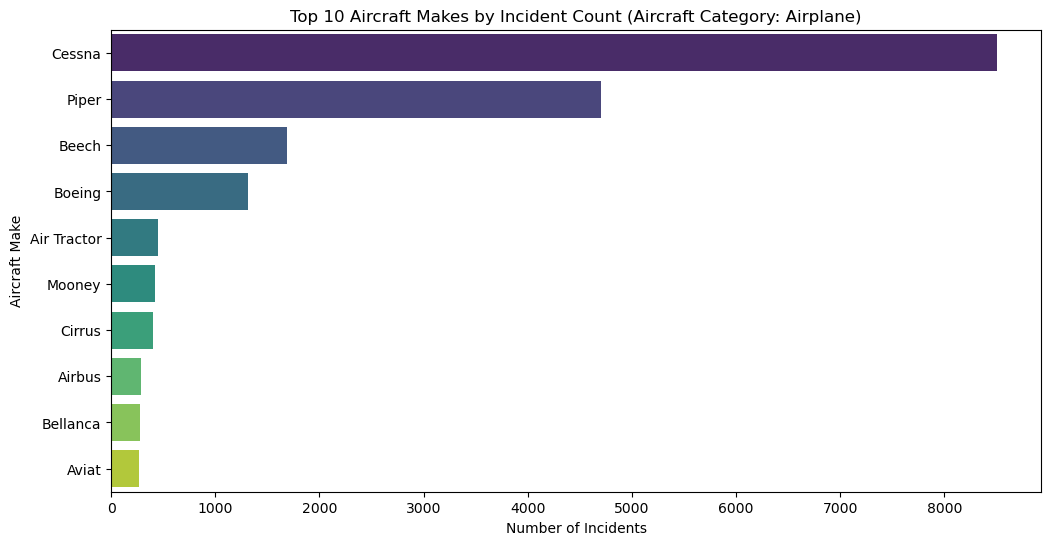

In [33]:
# The Top 10 Aircraft Makes by Incident Count
make_incidents = df_filtered['Make'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=make_incidents.values, y=make_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title('Top 10 Aircraft Makes by Incident Count (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Make')
plt.show()

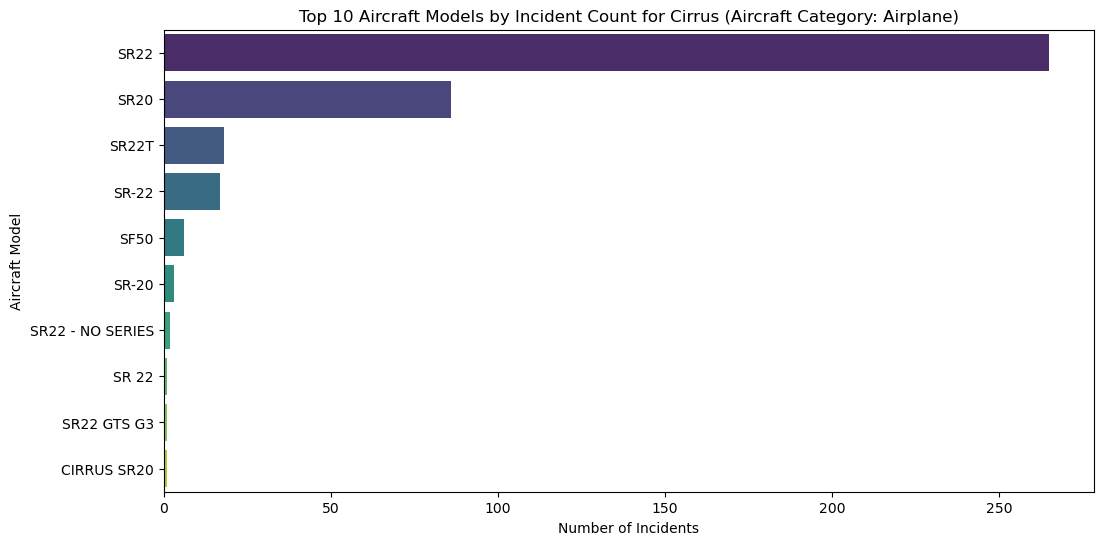

In [34]:
# Top 10 Aircraft Models by Incident Count which we will filter by Make and focus on the lowest count incidents of make
# Example: Let's look at models for the top Make(10) (e.g., Cirrus, Airbus,Bellanca and Aviat)
 # Get the make through indexing the top 10 most frequent make 
top_make_6 = make_incidents.index[6] # Cirrus 
top_make_7 = make_incidents.index[7] # Airbus
top_make_8 =make_incidents.index[8] # Bellanca
top_make_9 = make_incidents.index[9] # Aviat

model_incidents = df_filtered[df_filtered['Make'] == top_make_6]['Model'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot( x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis',legend=False )
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make_6} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

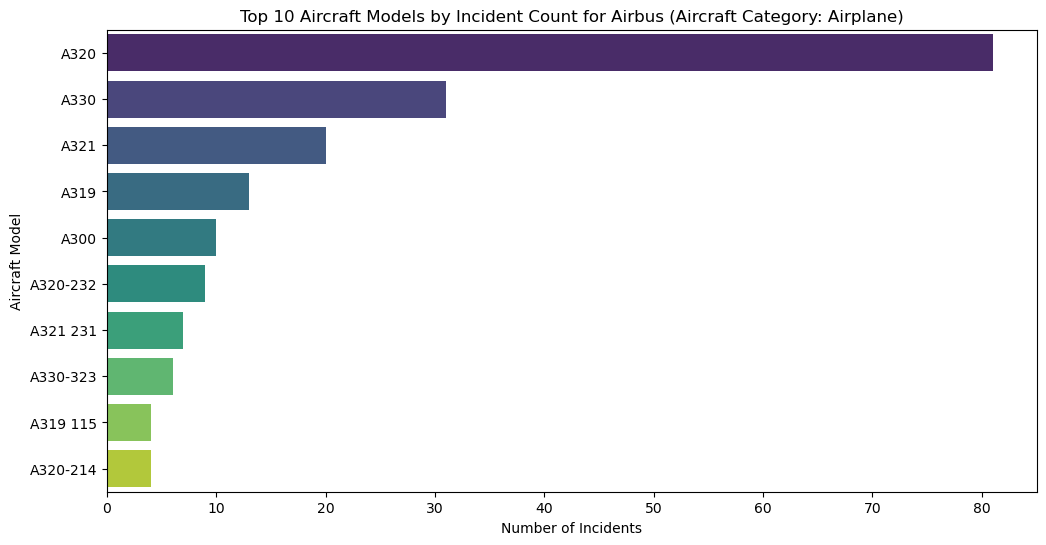

In [35]:
#  Models by Incident Count Boeing
model_incidents = df_filtered[df_filtered['Make'] == top_make_7]['Model'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make_7} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

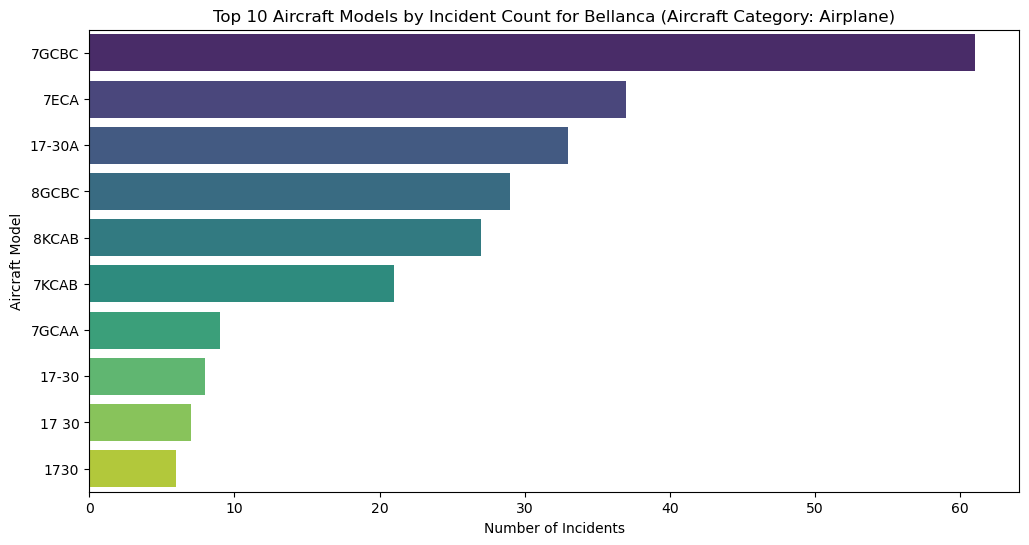

In [36]:
#  Models by Incident Count Airbus
model_incidents = df_filtered[df_filtered['Make'] == top_make_8]['Model'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make_8} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

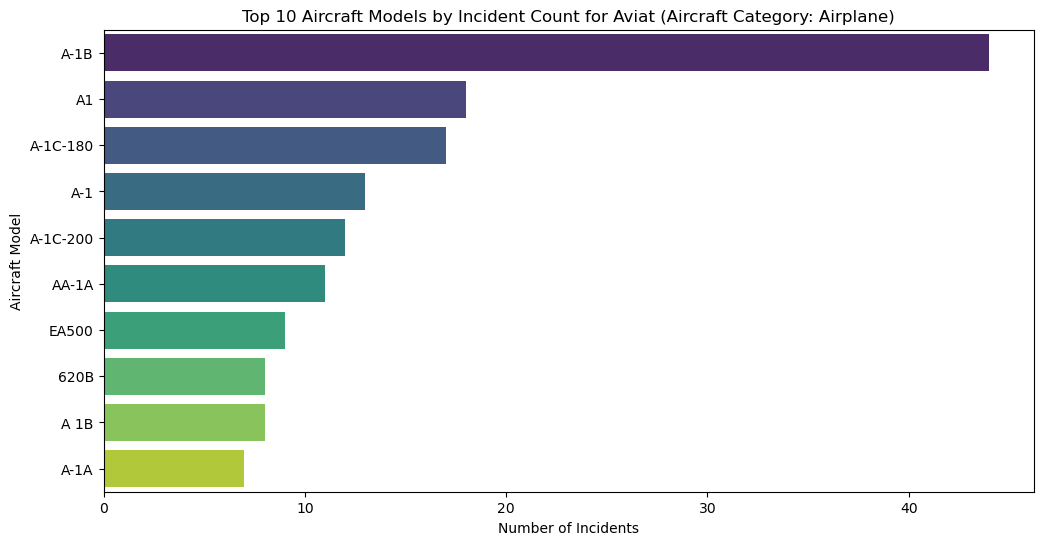

In [37]:
#  Models by Incident Count Aviat
model_incidents = df_filtered[df_filtered['Make'] == top_make_9]['Model'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make_9} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

#### B. Severity of Incidents by Aircraft Damage
* This directly addresses the financial implications of incidents. "Destroyed" or "Substantial" damage means high costs.

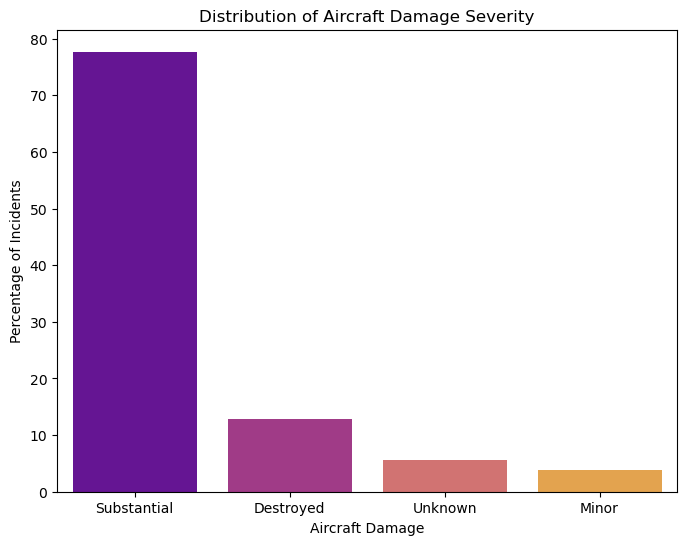

In [38]:
# Distribution of Aircraft Damage in percentage
damage_distribution = df_filtered['Aircraft_damage'].value_counts(normalize=True) * 100


plt.figure(figsize=(8, 6))
sns.barplot(x=damage_distribution.index, y=damage_distribution.values, hue=damage_distribution.index, palette='plasma', legend=False)
plt.title('Distribution of Aircraft Damage Severity')
plt.xlabel('Aircraft Damage')
plt.ylabel('Percentage of Incidents')
plt.show()

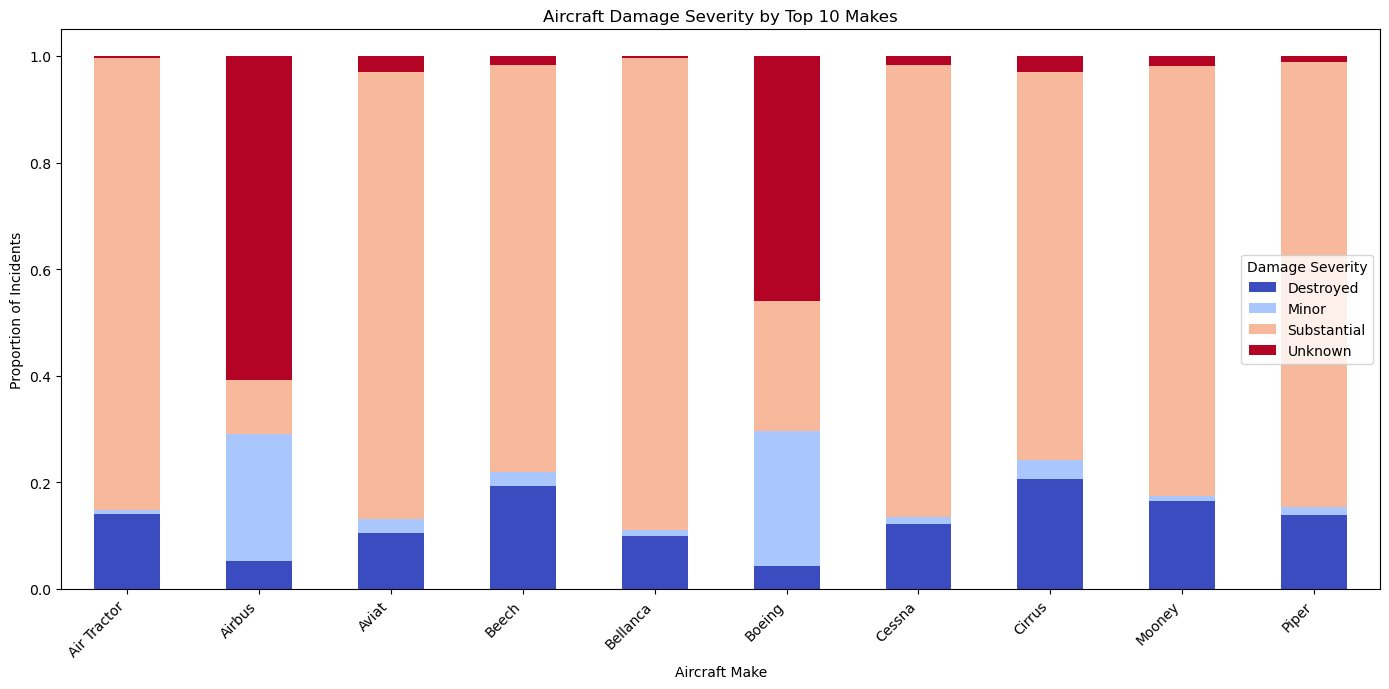

In [39]:
# Damage severity by Make top 5 makes
top_10_makes = df_filtered['Make'].value_counts().head(10).index
damage_by_make = df_filtered[df_filtered['Make'].isin(top_10_makes)].groupby('Make')['Aircraft_damage'].value_counts(normalize=True).unstack(fill_value=0)


damage_by_make.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='coolwarm')
plt.title('Aircraft Damage Severity by Top 10 Makes')
plt.xlabel('Aircraft Make')
plt.ylabel('Proportion of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Damage Severity')
plt.tight_layout()
plt.show()

#### C. Human Impact: Injury Severity
 * This is about the human cost. High numbers of fatalities or serious injuries indicate a higher "safety risk" profile for an aircraft type.

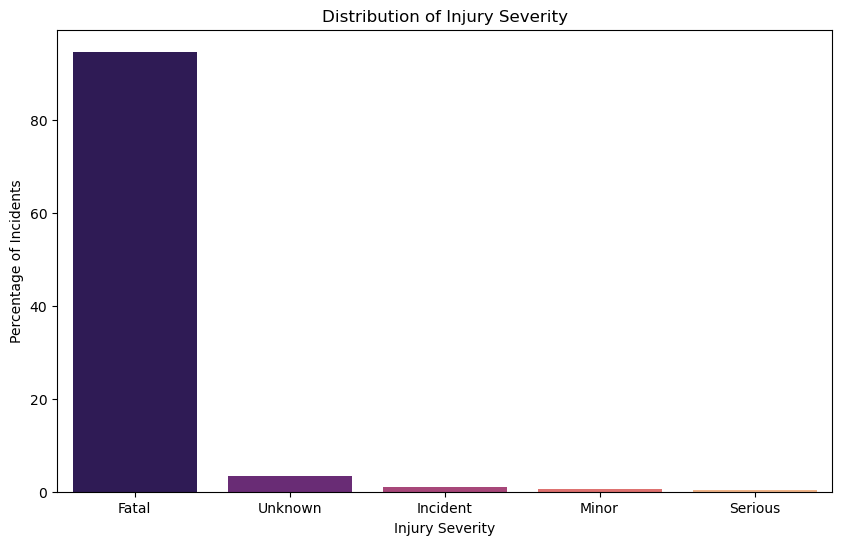

In [40]:
# Distribution of Injury Severity in percentage
injury_distribution = df_filtered['Injury_Severity'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=injury_distribution.index, y=injury_distribution.values,  hue = injury_distribution.index, palette='magma', legend=False)
plt.title('Distribution of Injury Severity')
plt.xlabel('Injury Severity')
plt.ylabel('Percentage of Incidents')
plt.show()

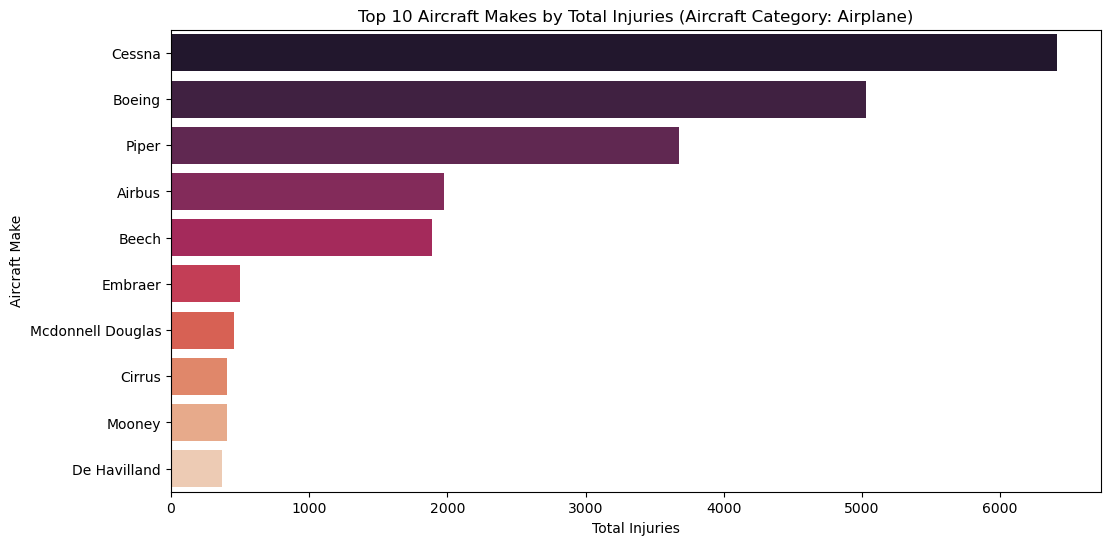

In [41]:
# Total Injuries by Make requires aggregate of all injury columns
df_filtered['Total_Injuries'] = df_filtered['Total_Fatal_Injuries'] + df_filtered['Total_Serious_Injuries'] + df_filtered['Total_Minor_Injuries']

total_injuries_by_make = df_filtered.groupby('Make')['Total_Injuries'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=total_injuries_by_make.values, y=total_injuries_by_make.index, hue=total_injuries_by_make.index, palette='rocket', legend=False)
plt.title('Top 10 Aircraft Makes by Total Injuries (Aircraft Category: Airplane)')
plt.xlabel('Total Injuries')
plt.ylabel('Aircraft Make')
plt.show()

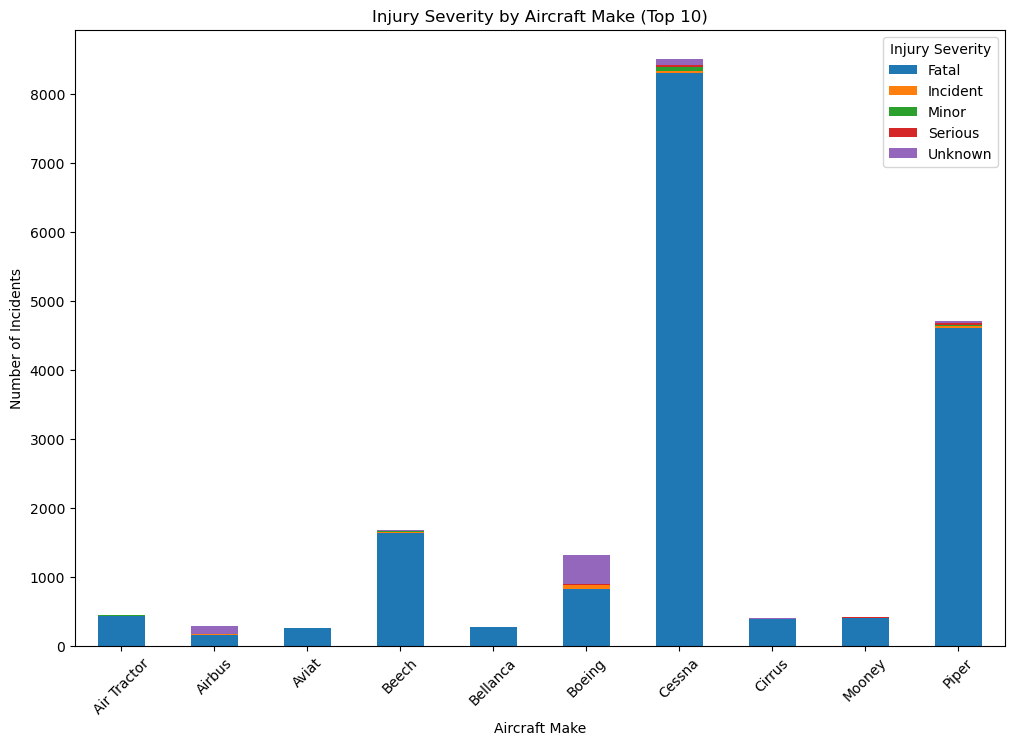

In [42]:
# Injuries Severity by Make in the top 10
# Get the top 10 makes
top_10_makes = df_filtered['Make'].value_counts().head(10).index

# Filter the DataFrame to include only the top 10 makes
df_top_10_makes = df_filtered[df_filtered['Make'].isin(top_10_makes)]

make_injury = df_top_10_makes.groupby(['Make', 'Injury_Severity']).size().unstack(fill_value=0)

# Create the stacked bar chart
make_injury.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Injury Severity by Aircraft Make (Top 10)')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Injury Severity')
plt.show()

### D. Operational Context: Purpose of Flight & Broad Phase of Flight
 * Purpose_of_flight, Weather_Condition and Broad_phase_of_flight will give us insights into the circumstances of accidents.
   For instance, if a specific aircraft model has a high number of landing accidents, it might suggest a design or operational characteristic that makes landing more challenging for that type.

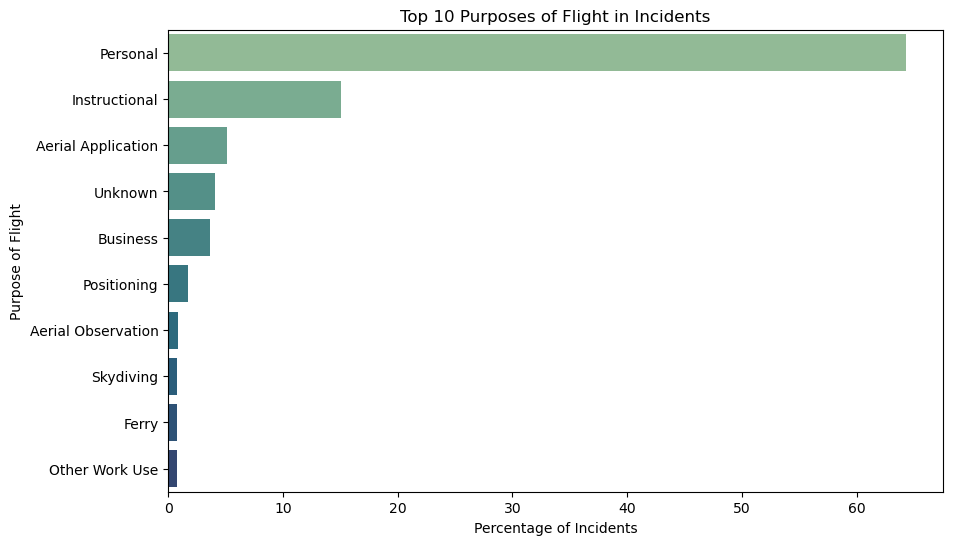

In [43]:
# Distribution of Purpose of Flight in Incidents
purpose_distribution = df_filtered['Purpose_of_flight'].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=purpose_distribution.values, y=purpose_distribution.index, hue=purpose_distribution.index, palette='crest', legend=False)
plt.title('Top 10 Purposes of Flight in Incidents')
plt.xlabel('Percentage of Incidents')
plt.ylabel('Purpose of Flight')
plt.show()

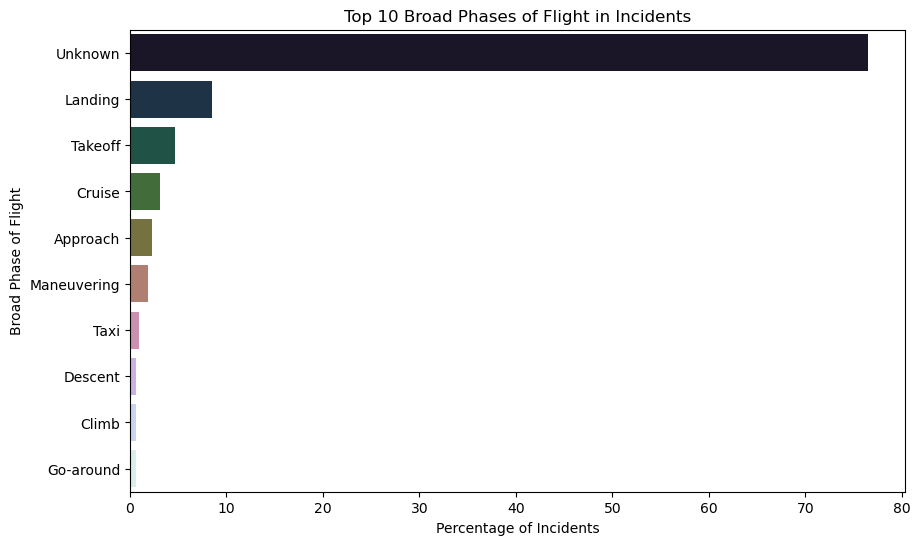

In [44]:
# Distribution of Broad Phase of Flight in Incidents
phase_distribution = df_filtered['Broad_phase_of_flight'].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=phase_distribution.values, y=phase_distribution.index, hue=phase_distribution.index, palette='cubehelix', legend = False)
plt.title('Top 10 Broad Phases of Flight in Incidents')
plt.xlabel('Percentage of Incidents')
plt.ylabel('Broad Phase of Flight')
plt.show()

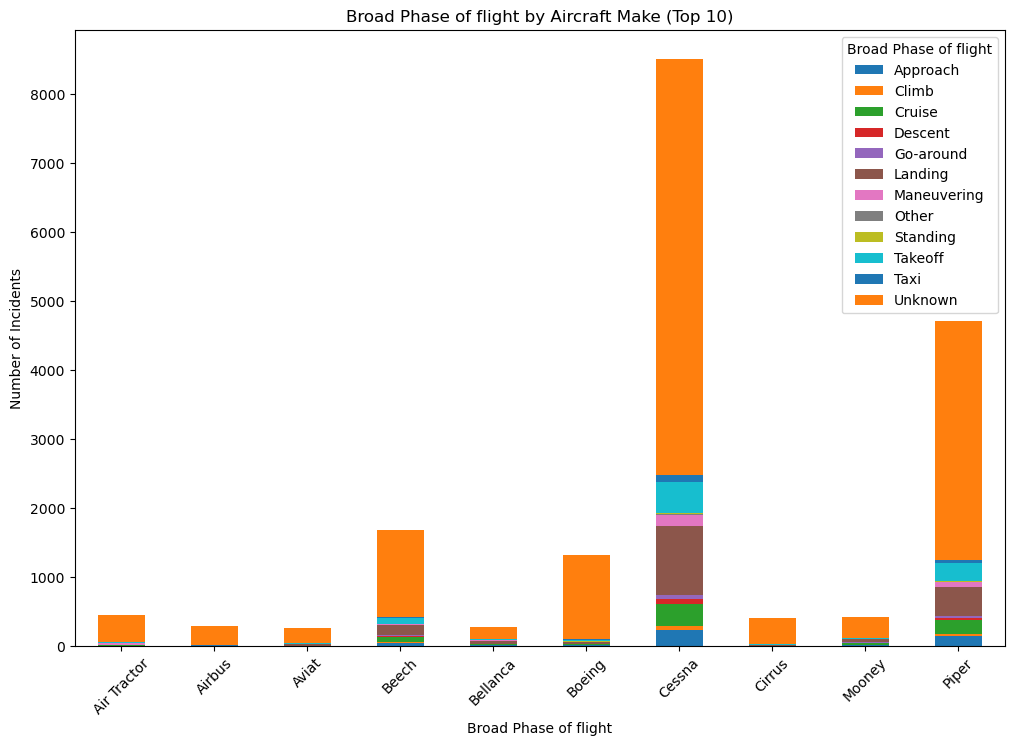

In [45]:
# Broad Phase of Flight by Make in the top 10
# Get the top 10 makes
top_10_makes = df_filtered['Make'].value_counts().head(10).index

# Filter the DataFrame to include only the top 10 makes
df_top_10_makes = df_filtered[df_filtered['Make'].isin(top_10_makes)]

Broad_Phase = df_top_10_makes.groupby(['Make', 'Broad_phase_of_flight']).size().unstack(fill_value=0)

# bar chart
Broad_Phase.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Broad Phase of flight by Aircraft Make (Top 10)')
plt.xlabel('Broad Phase of flight')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Broad Phase of flight')
plt.show()

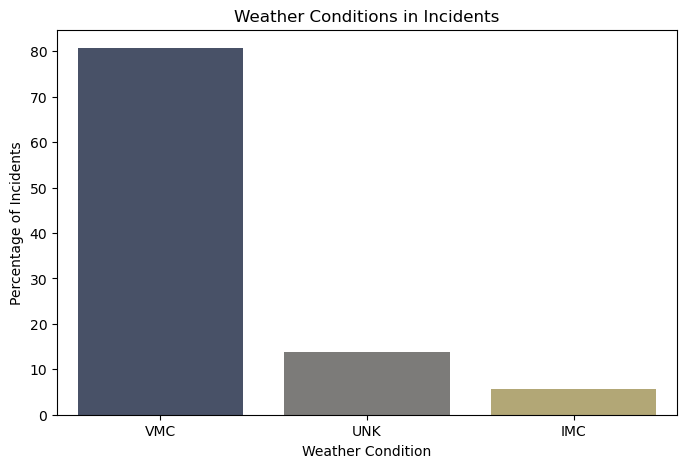

In [46]:
# Weather Conditions Impact
# Distribution of Weather Conditions in Incidents
weather_distribution = df_filtered['Weather_Condition'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_distribution.index, y=weather_distribution.values, hue=weather_distribution.index, palette='cividis',legend= False)
plt.title('Weather Conditions in Incidents')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage of Incidents')
plt.show()

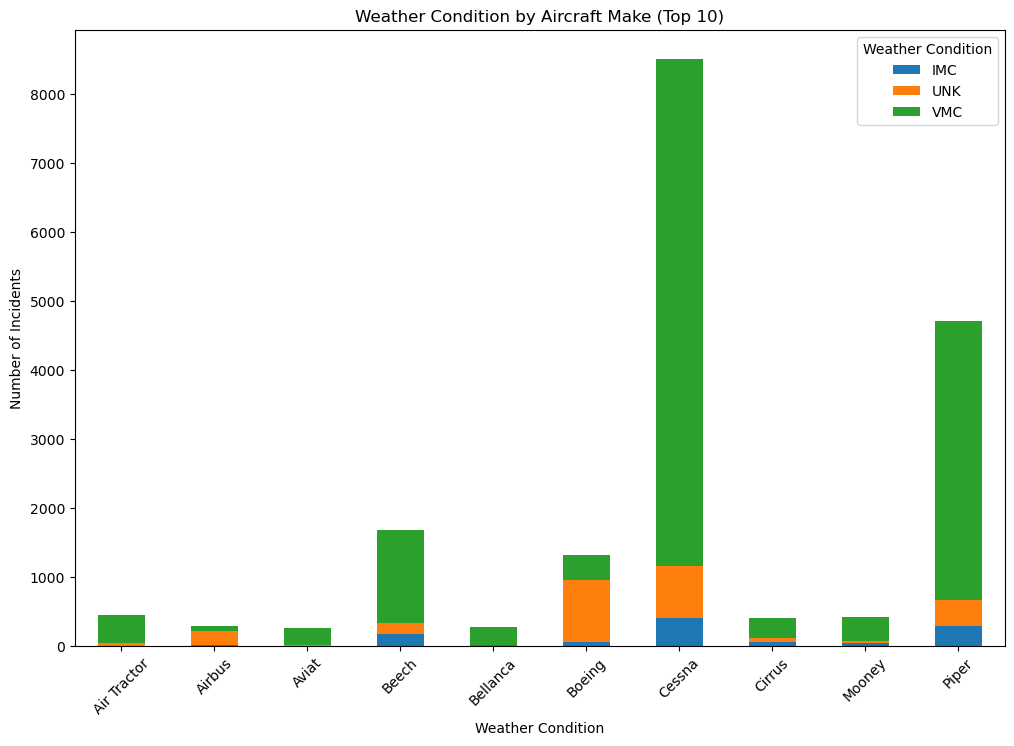

In [47]:
# Weather Conditions by Make in the top 10
# Get the top 10 makes
top_10_makes = df_filtered['Make'].value_counts().head(10).index

# Filter the DataFrame to include only the top 10 makes
df_top_10_makes = df_filtered[df_filtered['Make'].isin(top_10_makes)]

Weather_condition = df_top_10_makes.groupby(['Make', 'Weather_Condition']).size().unstack(fill_value=0)

# bar chart
Weather_condition.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Weather Condition by Aircraft Make (Top 10)')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Weather Condition')
plt.show()

In [48]:
df_filtered.to_csv('cleaned_aviation_data.csv', index=False)

## 5. Summary and Interpretation of Findings

##### Based on this dataset- accident data, the primary risk factors associated with aircraft ownership and operation, quantifiable through this dataset, include:
* **Accident Frequency/Rates:** Certain aircraft Makes (e.g., Cessna, Piper) have a higher number of recorded incidents. While not a true 'rate' without fleet data, higher counts indicate higher exposure to incidents.")
* **Aircraft Damage Severity:** A large proportion of incidents result in 'Substantial' damage, indicating significant financial cost for repairs or replacement.")
* **Human Injury/Fatality Rates:** The occurrence of fatal, serious, and minor injuries is a critical risk factor, both from a human capital and liability perspective.")
* **Operational Phase Vulnerabilities:** Specific phases of flight (e.g., Landing, Takeoff) are significantly more prone to incidents for all aircraft, suggesting these are high-risk operational periods.")
* **Weather Conditions:** While VMC is most common, understanding incidents in IMC (Instrument Meteorological Conditions) or unknown conditions is important for assessing all-weather operational risk.")
* **Purpose of Flight:** Incidents vary by flight purpose but personal appears to be the most common.

*NOTE*: To truly determine 'lowest risk,' we will would need to cross-reference these findings with external data on maintenance costs, fuel efficiency, spare parts availability, and aircraft market value/depreciation.")

## 6. Business recommendations
Based on the analysis of the aviation incident dataset which focussed on accident frequency, damage severity, and human impact, here are three concrete business recommendations for the Head of the New Aviation Division:


### i. Prioritize Aircraft Acquisition of Low-Incidence, Low-Severity Make, I would recommend *Airbus*, *Bellanca* and *Maule*.
**Rationale**: The analysis indicates that these specific aircraft types exhibit the lowest combined risk profiles (lower number of total incidents, a reduced proportion of severe (destroyed or substantial) damage, and fewer occurrences of fatal or serious injuries. These makes will make the most sense for initial acquisition and hence mitigates the most significant operational, financial, and safety risks associated with entering the aviation sector.

**Actionable Step**: Immediately initiate deeper financial and operational due diligence (e.g., total cost of ownership, spare parts availability, pilot training requirements, maintenance schedules) focusing exclusively on these top-tier, low-risk models before expanding the search to other aircraft.

### ii. Develop and Enforce Rigorous Standard Operating Procedures (SOPs) and Enhanced Pilot Training Curricula Concentrating on        *Takeoff* and *Landing* Phases across the entire fleet.

**Rationale**: Implement Enhanced Training and Operational Procedures Focused on Broad Phase of Flight, e.g., Landing, Takeoff for All Aircraft Acquired, as these Phases Account for the Majority of Incidents Across Most Aircraft Types." Proactive risk mitigation in these areas will yield the greatest safety dividends.

**Actionable Step**: Design mandatory, recurrent simulator training modules specifically addressing common incident scenarios during takeoff and landing (e.g., engine failure on takeoff, crosswind landings, go-around procedures). Implement strict pilot proficiency checks and continuous re-evaluation focusing on these high-risk phases, even for experienced aircrew.

### iii. Establish a Robust Risk Monitoring Framework that Continuously Tracks Incident Data for the Acquired Fleet and Develops a     Contingency Fund for Severe Aircraft Damage.

**Rationale**: While historical data informs initial choices, aviation risks are dynamic. A proportion of incidents, even in "low-risk" aircraft, still result in substantial or destroyed damage, indicating significant potential financial exposure. Proactive monitoring identifies emerging risks, and a dedicated fund prepares for inevitable high-cost events.

**Actionable Step**: Implement a system to regularly review updated incident data for the specific makes and models purchased, identifying any new trends or emerging safety alerts. 